In [ ]:
from google.colab import drive
import os

gdrive_path='/content/gdrive/MyDrive/ddpm'

# This will mount your google drive under 'MyDrive'
drive.mount('/content/gdrive', force_remount=True)
# In order to access the files in this notebook we have to navigate to the correct folder
os.chdir(gdrive_path)
# Check manually if all files are present
print(sorted(os.listdir()))

In [ ]:
!pip install --quiet -r requirements.txt

In [1]:
import os

import math
from collections import defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from tqdm import tqdm

from ddpm import DDPM
from visualization import visualize_dataset_mnist, visualize_mnist_samples, plot_image_grid

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

plot_dir = "plots"
os.makedirs(plot_dir, exist_ok=True)
print(f"Plots will be saved to '{plot_dir}/'")

checkpoint_dir = "checkpoints_ddpm"
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"Checkpoints will be saved to '{checkpoint_dir}/'")

Using device: cpu
Plots will be saved to 'plots/'
Checkpoints will be saved to 'checkpoints_ddpm/'


### Load MNIST dataset

In [3]:
batch_size = 128
tfs = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])
train_data = datasets.MNIST("./data", train=True, download=True, transform=tfs)
test_data = datasets.MNIST("./data", train=False, download=True, transform=tfs)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=1, pin_memory=device.type == "cuda")
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=1, pin_memory=device.type == "cuda")

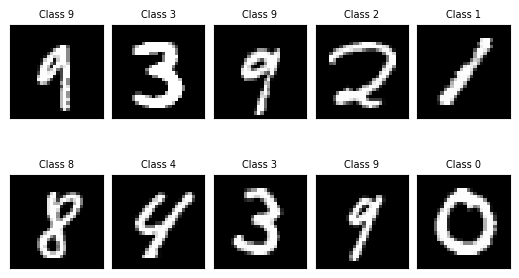

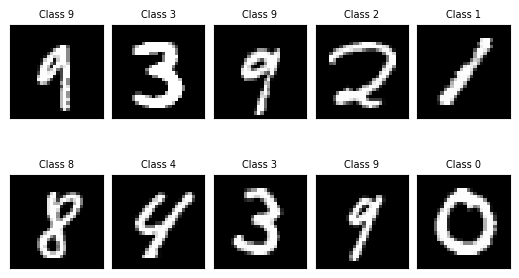

In [4]:
visualize_dataset_mnist(train_data)

### Model initialization

In [5]:
N_STEPS = 1000
IN_CHANNELS = 1
IMAGE_SIZE = 28
HIDDEN_DIM = 32
N_LAYERS = 2

ddpm = DDPM(
    N=N_STEPS,
    type="unet",
    hidden_dim=HIDDEN_DIM,
    n_layers=N_LAYERS,
    in_channels=IN_CHANNELS,
    image_size=IMAGE_SIZE,
    beta_schedule="linear",
    var_schedule="fixed",
    loss_type="simple"
).to(device)

opt = torch.optim.Adam(ddpm.parameters())

### Forward process

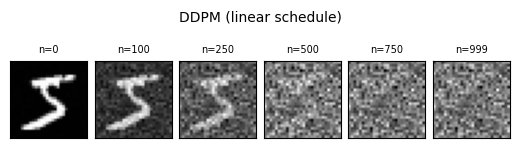

In [6]:
def visualize_forward_process(model, title, filename):
    x0, _ = train_data[0]
    x0 = x0.unsqueeze(0).to(device)

    timesteps = torch.tensor([0, 100, 250, 500, 750, 999], device=device)
    noisy_images = []
    labels = []

    epsilon = torch.randn_like(x0)

    for n in timesteps:
        alpha_bar_n = model.alpha_bar[n]
        x_n = torch.sqrt(alpha_bar_n) * x0 + torch.sqrt(1 - alpha_bar_n) * epsilon
        noisy_images.append(x_n.squeeze(0).cpu().numpy())
        labels.append(f"n={n.item()}")

    fig = plot_image_grid(noisy_images, labels, ncols=6)
    fig.suptitle(title, y=1.1, fontsize=10)

    filepath = os.path.join(plot_dir, filename)
    plt.savefig(filepath)
    plt.show()

visualize_forward_process(
    ddpm,
    "DDPM (linear schedule)",
    "01_forward_process.png"
)

### Model training

In [7]:
def train_model(model, optimizer, max_epochs, model_name, checkpoint_dir, start_epoch=0, initial_losses=None):
    if initial_losses is None:
        all_losses = defaultdict(list)
    else:
        all_losses = initial_losses

    print(f"--- Starting training for: {model_name} (from epoch {start_epoch+1}) ---")

    for epoch in range(start_epoch, max_epochs):
        epoch_losses = defaultdict(list)

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs}")
        for ix, (x, y) in enumerate(pbar):
            x = x.to(device)

            loss_dict = model.loss(x)
            loss = loss_dict["total_loss"]

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            for k, v in loss_dict.items():
                batch_loss_val = v.item()
                epoch_losses[k].append(batch_loss_val)
                all_losses[k].append(batch_loss_val)

            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        print(f"  => Epoch {epoch+1} complete. Mean Loss: {np.mean(epoch_losses['total_loss']):.4f}")

        checkpoint_path = os.path.join(checkpoint_dir, f"{model_name}_latest.pth")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'losses': all_losses,
        }, checkpoint_path)

    print(f"--- Finished training for: {model_name} ---")
    return all_losses

MAX_EPOCHS = 20

#### Checkpoint-loading

In [8]:
start_epoch_ddpm = 20
losses_ddpm = None
checkpoint_path = os.path.join(checkpoint_dir, "ddpm_latest.pth")

if os.path.isfile(checkpoint_path):
    print(f"Loading checkpoint for 'DDPM': {checkpoint_path}")

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    ddpm.load_state_dict(checkpoint['model_state_dict'], strict=False)
    opt.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch_ddpm = checkpoint['epoch']
    losses_ddpm = checkpoint['losses']

    print(f"  => Resuming 'DDPM' from epoch {start_epoch_ddpm + 1}")
else:
    print("Starting 'DDPM' training from scratch.")

Loading checkpoint for 'DDPM': checkpoints_ddpm/ddpm_latest.pth
  => Resuming 'DDPM' from epoch 21


#### Model training

In [9]:
if start_epoch_ddpm < MAX_EPOCHS:
    losses_ddpm = train_model(
        ddpm,
        opt,
        MAX_EPOCHS,
        "ddpm",
        checkpoint_dir,
        start_epoch=start_epoch_ddpm,
        initial_losses=losses_ddpm
    )
else:
    print(f"'DDPM' training is already complete (reached {start_epoch_ddpm} epochs).")

'DDPM' training is already complete (reached 20 epochs).


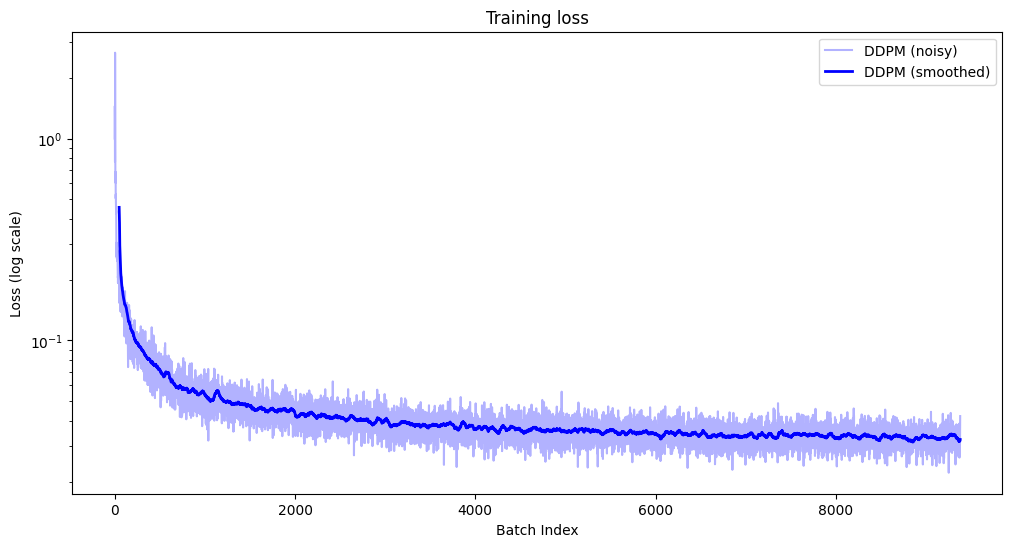

In [10]:
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

window = 50
plt.figure(figsize=(12, 6))

loss_data_ddpm = losses_ddpm['total_loss']
x_raw_ddpm = np.arange(len(loss_data_ddpm))
plt.plot(
    x_raw_ddpm,
    loss_data_ddpm,
    label="DDPM (noisy)",
    alpha=0.3,
    color='blue'
)
smooth_losses_ddpm = moving_average(loss_data_ddpm, window)
x_smooth_ddpm = np.arange(window - 1, len(loss_data_ddpm))
plt.plot(
    x_smooth_ddpm,
    smooth_losses_ddpm,
    label="DDPM (smoothed)",
    color='blue',
    linewidth=2
)


plt.title('Training loss')
plt.xlabel('Batch Index')
plt.ylabel('Loss (log scale)')
plt.legend()
plt.yscale('log')
# plt.ylim(0, 0.4)

filepath = os.path.join(plot_dir, "03_loss_ddpm.png")
plt.savefig(filepath)
plt.show()

### Sampling

Sampling from DDPM


Sampling (full 1000 steps)...: 100%|████████| 1000/1000 [06:09<00:00,  2.71it/s]


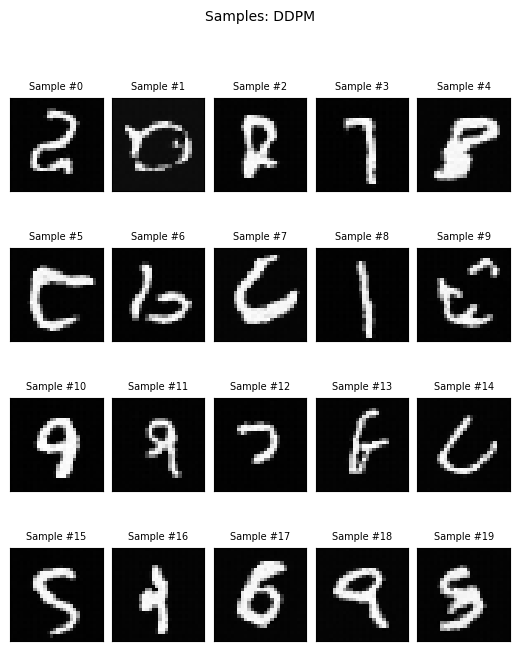

In [11]:
def generate_and_save_samples(model, model_name, filename, num_steps=-1):
    title = f"Samples: {model_name}"
    print(f"Sampling from {model_name}")

    with torch.no_grad():
        samples = model.sample(20, device, num_steps=num_steps)

    fig = visualize_mnist_samples(samples)
    fig.suptitle(title, y=1.1, fontsize=10)

    filepath = os.path.join(plot_dir, filename)
    fig.savefig(filepath)
    plt.show()

generate_and_save_samples(
    ddpm,
    "DDPM",
    "04_samples_ddpm.png"
    # num_steps=-1
)

### Reverse process

In [12]:
def visualize_reverse_process(model, title, filename, num_steps=-1, num_plots=5):
    """
    Visualizes the reverse process, supporting both full and strided sampling.
    """
    print(f"Visualizing reverse process for: {title}")
    num_samples = 5

    if num_steps <= 0 or num_steps > model.N:
        timesteps = list(reversed(range(model.N)))
        total_steps = model.N
        desc = f"Sampling (full {model.N} steps)..."
    else:
        timesteps = torch.linspace(model.N - 1, 0, num_steps, device=device).round().long().tolist()
        total_steps = num_steps
        desc = f"Sampling ({num_steps} steps)..."

    plot_indices = np.linspace(0, len(timesteps) - 1, num_plots, dtype=int)
    timesteps_to_plot = [timesteps[i] for i in plot_indices]

    image_shape = (model.in_channels, model.image_size, model.image_size)
    z_n = torch.randn((num_samples, *image_shape), device=device)

    intermediate_samples = []
    with torch.no_grad():
        for n in tqdm(timesteps, total=total_steps, desc=desc):
            n_tensor = torch.full((num_samples,), n, dtype=torch.long, device=device)

            if n in timesteps_to_plot:
                intermediate_samples.append((n, z_n.cpu()))

            normalized_n = n_tensor.float() / model.N
            model_output = model.model(z_n, normalized_n)
            z_n = model._p_sample(model_output, z_n, n_tensor)

    if timesteps[-1] not in timesteps_to_plot:
         intermediate_samples.append((timesteps[-1], z_n.cpu()))

    plot_images = []
    plot_labels = []

    intermediate_samples.sort(key=lambda x: x[0], reverse=True)

    for n, images_batch in intermediate_samples:
        for i in range(num_samples):
            plot_images.append(images_batch[i].squeeze(0))
            plot_labels.append(f"Sample {i+1}\nn={n}")

    fig = plot_image_grid(plot_images, plot_labels, ncols=num_samples)
    fig.suptitle(title, y=1.05, fontsize=10)

    filepath = os.path.join(plot_dir, filename)
    plt.savefig(filepath)
    print(f"Saved reverse process plot to {filepath}")
    plt.show()

Visualizing reverse process for: Reverse process: DDPM


Sampling (full 1000 steps)...: 100%|████████| 1000/1000 [00:31<00:00, 31.45it/s]


Saved reverse process plot to plots/06_reverse_process_ddpm.png


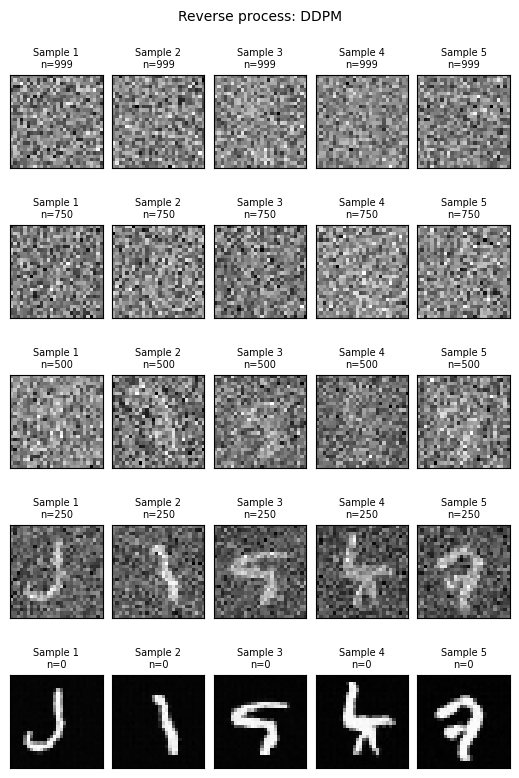

In [13]:
visualize_reverse_process(
    ddpm,
    "Reverse process: DDPM",
    "06_reverse_process_ddpm.png"
    # num_steps=-1 is default
)